In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"C:\Data analysis project\imdb_clean.csv")

In [8]:
df.head()

,Serial No.,title,director,release_year,runtime,genre,rating,metascore,gross(M)
0,0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
2,1,The Godfather,Francis Ford Coppola,1972,175,Drama,9.2,100,134.97
3,2,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86
4,2,The Dark Knight,Christopher Nolan,2008,152,Crime,9.0,84,534.86


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2532 entries, 0 to 2531
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Serial No.    2532 non-null   int64  
 1   title         2532 non-null   object 
 2   director      2532 non-null   object 
 3   release_year  2532 non-null   int64  
 4   runtime       2532 non-null   int64  
 5   genre         2532 non-null   object 
 6   rating        2532 non-null   float64
 7   metascore     2532 non-null   int64  
 8   gross(M)      2532 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 178.2+ KB


In [10]:
df.columns

Index(['Serial No.', 'title', 'director', 'release_year', 'runtime', 'genre',
       'rating', 'metascore', 'gross(M)'],
      dtype='object')

In [11]:
df.columns = ['serial_no', 'title', 'director', 'release_year', 'runtime', 'genre', 'rating', 'metascore', 'gross_m']

In [12]:
df.head()

,serial_no,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
2,1,The Godfather,Francis Ford Coppola,1972,175,Drama,9.2,100,134.97
3,2,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86
4,2,The Dark Knight,Christopher Nolan,2008,152,Crime,9.0,84,534.86


In [13]:
df = df.drop("serial_no", axis=1)

In [14]:
df.head()

,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
2,The Godfather,Francis Ford Coppola,1972,175,Drama,9.2,100,134.97
3,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86
4,The Dark Knight,Christopher Nolan,2008,152,Crime,9.0,84,534.86


In [15]:
df.isnull().sum()

title           0
director        0
release_year    0
runtime         0
genre           0
rating          0
metascore       0
gross_m         0
dtype: int64

In [17]:
df.dtypes

title            object
director         object
release_year      int64
runtime           int64
genre            object
rating          float64
metascore         int64
gross_m         float64
dtype: object

In [18]:
df.head(10)

,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
2,The Godfather,Francis Ford Coppola,1972,175,Drama,9.2,100,134.97
3,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86
4,The Dark Knight,Christopher Nolan,2008,152,Crime,9.0,84,534.86
5,The Dark Knight,Christopher Nolan,2008,152,Drama,9.0,84,534.86
6,Schindler's List,Steven Spielberg,1993,195,Biography,9.0,95,96.90
7,Schindler's List,Steven Spielberg,1993,195,Drama,9.0,95,96.90
8,Schindler's List,Steven Spielberg,1993,195,History,9.0,95,96.90
9,12 Angry Men,Sidney Lumet,1957,96,Crime,9.0,97,4.36


In [19]:
df["rating"].max()

9.3

In [20]:
df[df["rating"] == df["rating"].max()]

,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34


In [21]:
df["genre"].value_counts()

genre
Drama        732
Comedy       229
Action       207
Crime        204
Adventure    189
Thriller     141
Romance      126
Biography    107
Mystery      103
Animation     84
Sci-Fi        67
Fantasy       62
Family        52
War           50
History       45
Horror        33
Music         31
Film-Noir     22
Western       17
Musical       16
Sport         15
Name: count, dtype: int64

In [22]:
df.groupby("genre")["rating"].mean().sort_values(ascending=False)

genre
Western      8.052941
War          8.050000
Crime        7.993137
Mystery      7.991262
Sci-Fi       7.986567
Action       7.986473
Adventure    7.982540
Drama        7.980191
Sport        7.980000
Film-Noir    7.977273
Biography    7.970093
Musical      7.943750
Animation    7.942857
Romance      7.938889
History      7.933333
Family       7.932692
Thriller     7.929787
Fantasy      7.925806
Comedy       7.911354
Music        7.909677
Horror       7.875758
Name: rating, dtype: float64

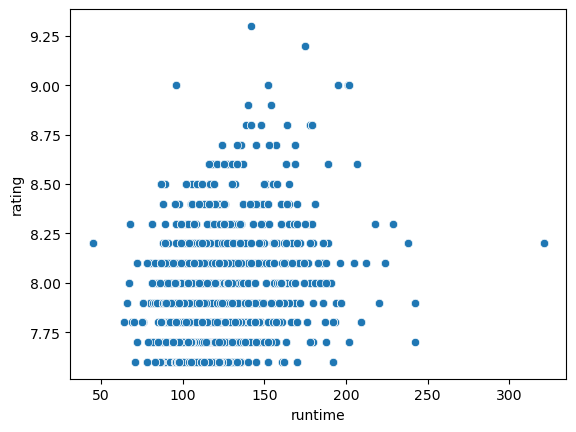

In [23]:
sns.scatterplot(x="runtime", y="rating", data=df)
plt.show()

In [24]:
df["genre"] = df["genre"].str.split(", ")

In [25]:
df = df.explode("genre")

In [26]:
df.head()

,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
2,The Godfather,Francis Ford Coppola,1972,175,Drama,9.2,100,134.97
3,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86
4,The Dark Knight,Christopher Nolan,2008,152,Crime,9.0,84,534.86


In [27]:
df.shape


(2532, 8)

In [28]:
df["genre"].head(10)

0        Drama
1        Crime
2        Drama
3       Action
4        Crime
5        Drama
6    Biography
7        Drama
8      History
9        Crime
Name: genre, dtype: object

In [29]:
df.sort_values(by="rating", ascending=False).head(10)

,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
2,The Godfather,Francis Ford Coppola,1972,175,Drama,9.2,100,134.97
1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
9,12 Angry Men,Sidney Lumet,1957,96,Crime,9.0,97,4.36
14,The Godfather Part II,Francis Ford Coppola,1974,202,Crime,9.0,90,57.30
13,The Lord of the Rings: The Return of the King,Peter Jackson,2003,201,Drama,9.0,94,377.85
12,The Lord of the Rings: The Return of the King,Peter Jackson,2003,201,Adventure,9.0,94,377.85
11,The Lord of the Rings: The Return of the King,Peter Jackson,2003,201,Action,9.0,94,377.85
10,12 Angry Men,Sidney Lumet,1957,96,Drama,9.0,97,4.36
15,The Godfather Part II,Francis Ford Coppola,1974,202,Drama,9.0,90,57.30


In [30]:
df_unique = df.drop_duplicates(subset="title")

In [31]:
df_unique.head()

,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
3,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86
6,Schindler's List,Steven Spielberg,1993,195,Biography,9.0,95,96.90
9,12 Angry Men,Sidney Lumet,1957,96,Crime,9.0,97,4.36


In [32]:
df_unique.sort_values(by="rating", ascending=False).head(10)

,title,director,release_year,runtime,genre,rating,metascore,gross_m
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97
3,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86
6,Schindler's List,Steven Spielberg,1993,195,Biography,9.0,95,96.90
9,12 Angry Men,Sidney Lumet,1957,96,Crime,9.0,97,4.36
11,The Lord of the Rings: The Return of the King,Peter Jackson,2003,201,Action,9.0,94,377.85
14,The Godfather Part II,Francis Ford Coppola,1974,202,Crime,9.0,90,57.30
16,Spider-Man: Across the Spider-Verse,Joaquim Dos Santos,2023,140,Animation,8.9,86,0.00
19,Pulp Fiction,Quentin Tarantino,1994,154,Crime,8.9,95,107.93
30,"The Good, the Bad and the Ugly",Sergio Leone,1966,178,Adventure,8.8,90,6.10


In [33]:
df_unique.groupby("director")["rating"].mean().sort_values(ascending=False).head(10)

director
Frank Darabont        8.95
Joaquim Dos Santos    8.90
T.J. Gnanavel         8.80
Kiranraj K            8.80
Irvin Kershner        8.70
Sudha Kongara         8.70
Madhavan              8.70
Lana Wachowski        8.70
Masaki Kobayashi      8.60
Roberto Benigni       8.60
Name: rating, dtype: float64

In [34]:
df_unique["director"].value_counts().head(10)

director
Alfred Hitchcock    12
Akira Kurosawa      12
Steven Spielberg    11
Martin Scorsese     10
Hayao Miyazaki      10
Billy Wilder         9
Ingmar Bergman       9
Stanley Kubrick      9
Woody Allen          9
Clint Eastwood       8
Name: count, dtype: int64

In [35]:
director_counts = df_unique["director"].value_counts()

In [36]:
valid_directors = director_counts[director_counts >= 5].index

In [37]:
df_valid = df_unique[df_unique["director"].isin(valid_directors)]

In [38]:
df_valid.groupby("director")["rating"].mean().sort_values(ascending=False).head(10)

director
Christopher Nolan    8.475000
Peter Jackson        8.440000
Sergio Leone         8.340000
Charles Chaplin      8.316667
Stanley Kubrick      8.222222
Quentin Tarantino    8.187500
Akira Kurosawa       8.158333
Steven Spielberg     8.136364
Billy Wilder         8.133333
Martin Scorsese      8.130000
Name: rating, dtype: float64

In [39]:
top_directors = df_valid.groupby("director")["rating"].mean().sort_values(ascending=False).head(10)

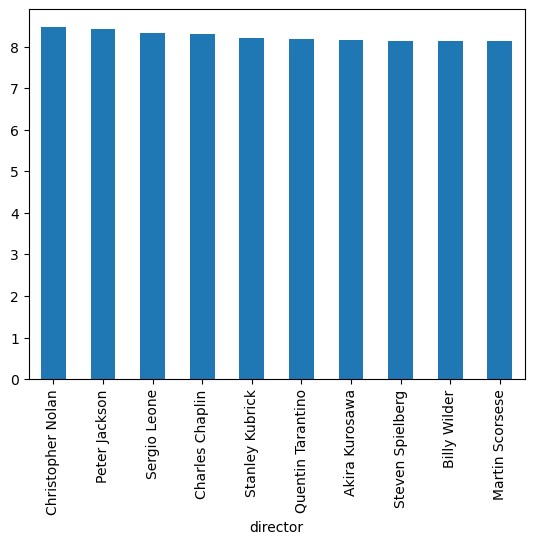

In [40]:
top_directors.plot(kind="bar")
plt.show()

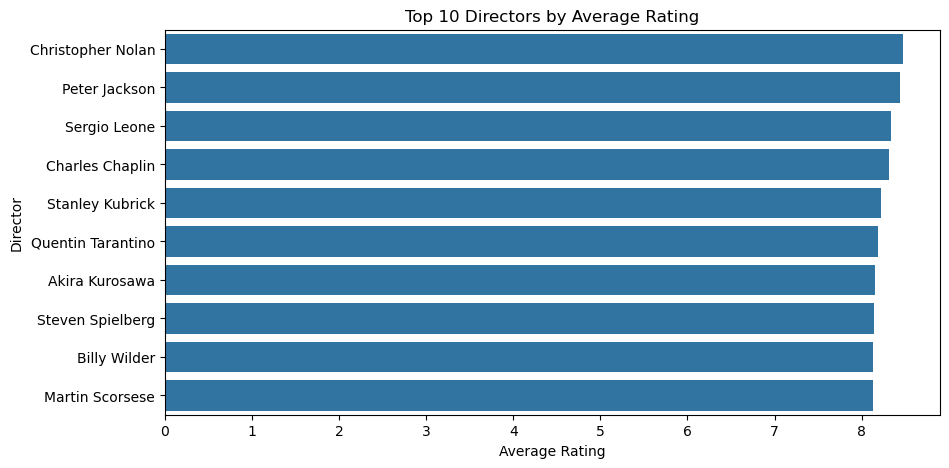

In [41]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.xlabel("Average Rating")
plt.ylabel("Director")
plt.title("Top 10 Directors by Average Rating")
plt.show()

In [42]:
genre_rating = df_unique.groupby("genre")["rating"].mean().sort_values(ascending=False).head(10)

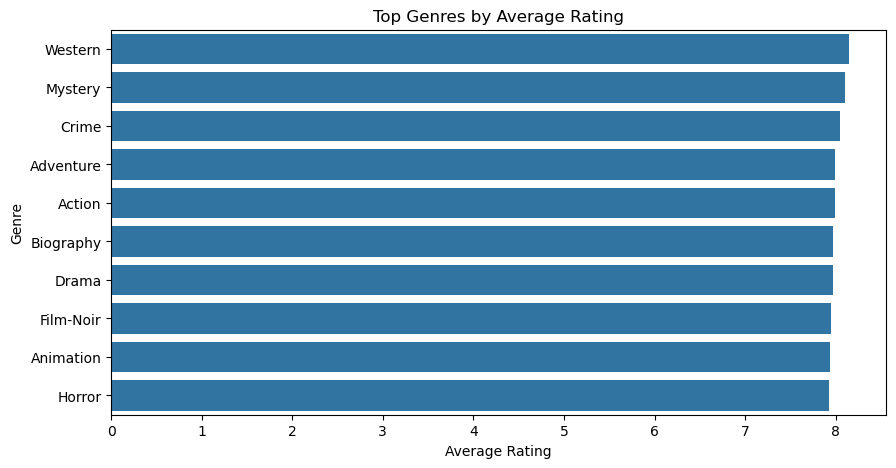

In [43]:
plt.figure(figsize=(10,5))
sns.barplot(x=genre_rating.values, y=genre_rating.index)
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Top Genres by Average Rating")
plt.show()

In [44]:
high_rated = df_unique[df_unique["rating"] >= 8]

In [45]:
high_rated["genre"].value_counts()

genre
Drama        143
Action        88
Crime         55
Comedy        55
Biography     44
Animation     39
Adventure     31
Mystery        7
Horror         5
Western        1
Film-Noir      1
Name: count, dtype: int64

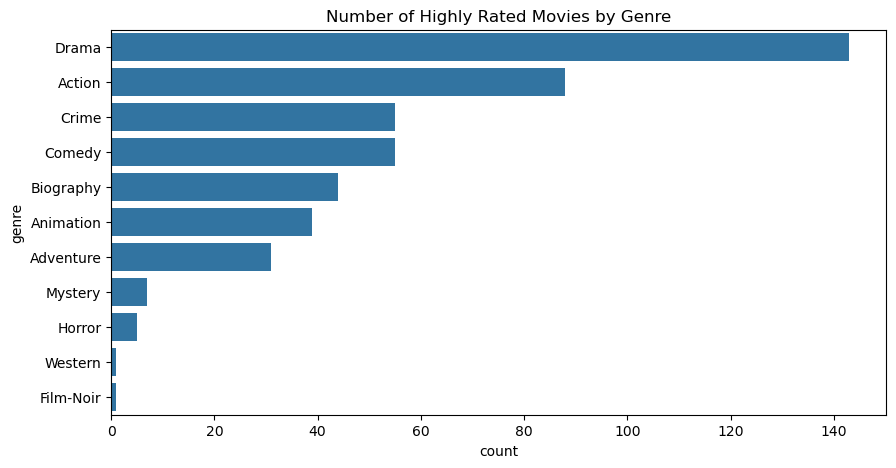

In [46]:
plt.figure(figsize=(10,5))
sns.countplot(y="genre", data=high_rated, order=high_rated["genre"].value_counts().index)
plt.title("Number of Highly Rated Movies by Genre")
plt.show()